## Fairness, Accountability, Transparency and Ethics Course (FATE)
## Universitat Pompeu Fabra (UPF)
### Academic Year 2026-2027
### Author: Morgan Gallagher (morgan.gallagher@upf.edu)
*** Based on the original exercises made by Ashwin Singh (ashwin.singh@tuwien.ac.at) ***

Submission date: February 19th at 11:59pm on Aula Global

Remember to submit this notebook **individually**.

# LAB 2: Algorithmic Fairness in Regression

<font size="+1">This lab consists of two sections: Discrimination in Salaries and Success in Law School. Each section is worth 5 points, for a total of 10 points. The point value for each question is indicated in brackets next to the question.</font>

Author: <font color="blue">Your name here</font>

E-mail: <font color="blue">Your e-mail here</font>

Date: <font color="blue">The current date here</font>

# Getting Started

## Installs & Imports

In [24]:
# !apt-get update -qq
# !apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

from prettytable import PrettyTable
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib
import warnings

warnings.filterwarnings(action="ignore")

# Discrimination in Salaries

> [Žliobaitė, I., Custers, B. Using sensitive personal data may be necessary for avoiding discrimination in data-driven decision models. Artificial Intelligence & Law 24, 183–201 (2016).](https://doi.org/10.1007/s10506-016-9182-5)

## Data Overview

This dataset contains the salaries of 52 faculty (38 Male, 14 Female) from a small midwestern college in United States from the early 1980s.


In [26]:
data_url = "https://raw.githubusercontent.com/mogallagher/UPF-FATE-2026/refs/heads/main/Lab%20II%20-%20Algorithmic%20Fairness/Data/salary.dat"

data = pd.read_fwf(data_url)

data.rename(
    columns={
        "sx":"sex",          # sex of the processor
        "rk":"rank",         # rank as a professor
        "dg":"degree",       # highest degree obtained
        "yd":"experience",   # years since highest degree ~ proxy for years of experience
        "sl":"salary"        # salary of the processor
    },
    inplace=True
)

# years spent in current rank, not relevant to the task
data.drop(columns=["yr"],inplace=True)

data.head()

,sex,rank,degree,experience,salary
0,male,full,doctorate,35,36350
1,male,full,doctorate,22,35350
2,male,full,doctorate,23,28200
3,female,full,doctorate,27,26775
4,male,full,masters,30,33696


## Exploratory Data Analysis

Look at the following plots and examine the data distributions. Do the data look biased?

**Things to consider:** (a) Which sex would you designate as the protected group and Why? (b) What are the main distributional differences between the protected and unprotected group in terms of how salary varies by years of experience, rank and degree?

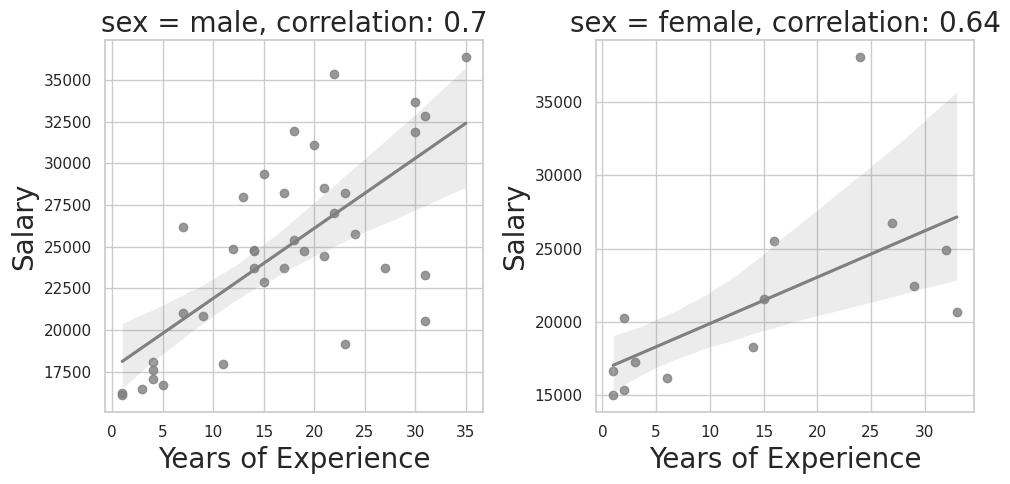

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2)

fig.set_figheight(5)
fig.set_figwidth(10)

sns.set_theme(style="whitegrid")

sns.regplot(
    data = data[data.sex=="male"],
    x = "experience",
    y = "salary",
    color = "gray",
    ax = ax1
)

sm, pm = pearsonr(
    data[data.sex=="male"].experience,
    data[data.sex=="male"].salary
)

ax1.set_title(
    f"sex = male, correlation: {round(sm,2)}",
    fontsize = 20
)
ax1.set_xlabel("Years of Experience", fontsize=20)
ax1.set_ylabel("Salary", fontsize=20)

sns.regplot(
    data = data[data.sex=="female"],
    x = "experience",
    y = "salary",
    color = "gray",
    ax = ax2
)

sf, pf = pearsonr(
    data[data.sex=="female"].experience,
    data[data.sex=="female"].salary
)

ax2.set_title(
    f"sex = female, correlation: {round(sf,2)}",
    fontsize = 20
)
ax2.set_ylabel("Salary", fontsize=20)
ax2.set_xlabel("Years of Experience", fontsize=20)

plt.tight_layout()
plt.show()

In [28]:
data.groupby("sex")["rank"].value_counts(normalize=True)

sex     rank     
female  assistant    0.571429
        full         0.285714
        associate    0.142857
male    full         0.421053
        associate    0.315789
        assistant    0.263158
Name: proportion, dtype: float64

In [29]:
data.groupby("sex").degree.value_counts(normalize=True)

sex     degree   
female  doctorate    0.714286
        masters      0.285714
male    doctorate    0.631579
        masters      0.368421
Name: proportion, dtype: float64

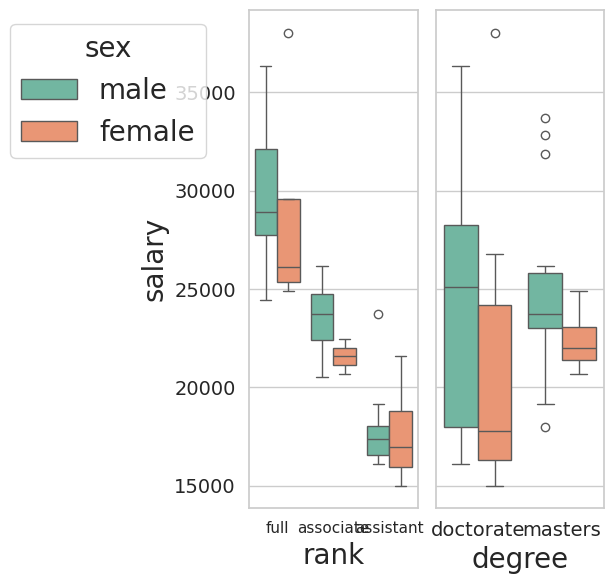

In [30]:
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(6)
fig.set_figwidth(8)

sns.boxplot(data=data, x="rank", y="salary", hue="sex", ax=ax1, palette="Set2")
sns.boxplot(data=data, x="degree", y="salary", hue="sex", ax=ax2, palette="Set2")

sns.move_legend(ax1, "upper left", bbox_to_anchor=(-1.5, 1), fontsize=20)
plt.setp(ax1.get_legend().get_title(), fontsize=20)
ax2.get_legend().set_visible(False)

L1 = [ ax1.xaxis.label, ax1.yaxis.label, ax2.xaxis.label ]
L2 = ax1.get_yticklabels() + ax2.get_xticklabels()
for item in L1: item.set_fontsize(20)
for item in L2: item.set_fontsize(14)

ax2.set_yticklabels([])
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

## Preprocessing Data

In [31]:
def preprocess(data):

    # encode ordinal variables on a scale of 1 to n
    data["rank"] = data["rank"].map(
        lambda rank: {"full":3, "associate":2, "assistant":1}[rank]
    )

    data.degree = data.degree.map(
        lambda degree: {"doctorate":2, "masters":1}[degree]
    )

    # encode gender as one-hot without introducing a dummy variable
    data.sex = data.sex.map(
        lambda sex: {"female":1, "male":0}[sex]
    )

    return data

processed = preprocess(data.copy())
processed.head()

,sex,rank,degree,experience,salary
0,0,3,2,35,36350
1,0,3,2,22,35350
2,0,3,2,23,28200
3,1,3,2,27,26775
4,0,3,1,30,33696


## A Test of Fairness via "Unawareness" - Linear Regression [1.5pts]

In this section, we will explore the implications of constructing so-called "blind" models, that is, models that explicitly exclude sensitive or confidential attributes during training. We will investigate whether removing these variables produces fairer predictions, or whether discrimination is perpetuated.

**Use the following two helper functions for the lab.**

In [32]:
def fit_regression_model(data,features,target):
    model = LinearRegression()
    model.fit(
        X = data[features],
        y = data[target]
    )
    return model

In [33]:
def make_regression_formula_table(models,sensitive=["sex"]):

    features = models["aware_model"].feature_names_in_

    table = PrettyTable(
        field_names = ["Model","intercept"] + list(features)
    )

    for model_name in models:

        model = models[model_name]
        coefs = list(model.coef_)
        for attribute in sensitive:
            if attribute not in model.feature_names_in_:
                coefs += [0]

        coefs = list(map(lambda x: round(x,3),coefs))
        intercept = round(model.intercept_,3)

        row = [model_name,intercept] + coefs
        table.add_row(row)

    print(table)

We construct four linear regression models.


*   `aware_model`: Trained on **all attributes**
*   `blind_model`: Trained on all attributes **except sex**
*   `m_model`: Trained on data where **sex is male**
*   `f_model`: Trained on data where **sex is female**


In [34]:
blind_features = ["rank", "degree", "experience"]
aware_features = blind_features + ["sex"]

models = {

    "aware_model":fit_regression_model(
        data = processed,
        features = aware_features,
        target = "salary"
    ),

    "blind_model":fit_regression_model(
        data = processed,
        features = blind_features,
        target = "salary"
    ),

    "m_model":fit_regression_model(
        data = processed[processed.sex==0],
        features = blind_features,
        target = "salary"
    ),

    "f_model":fit_regression_model(
        data = processed[processed.sex==1],
        features = blind_features,
        target = "salary"
    )
}

In [35]:
make_regression_formula_table(models)

+-------------+-----------+----------+----------+------------+----------+
|    Model    | intercept |   rank   |  degree  | experience |   sex    |
+-------------+-----------+----------+----------+------------+----------+
| aware_model | 11558.084 | 4993.251 | 397.715  |  102.948   | -950.046 |
| blind_model | 11424.746 | 5230.64  | 179.316  |   87.735   |    0     |
|   m_model   | 11736.019 | 5031.594 |  -30.61  |  129.252   |    0     |
|   f_model   |  7718.572 | 4567.12  | 2398.652 |   115.91   |    0     |
+-------------+-----------+----------+----------+------------+----------+


**[ 0.5 pts ]** **Interpret and compare** the intercept and coefficients of the blind and aware models. For example, the blind model's intercept is lower than the aware model's, what does this mean in practice?

**[ Answer ]**

**[ 0.5 pts ]** Explain how omitted variable bias can affect the performance of the blind model in comparison to the aware model.

**[ Answer ]**

In [36]:
processed["pred_aware"] = models["aware_model"].predict(processed[aware_features])
processed["pred_blind"] = models["blind_model"].predict(processed[blind_features])

df_m, df_f = processed[processed.sex==0], processed[processed.sex==1]

error_table = PrettyTable(field_names = ["model","error_male","error_female"])

em_aware = root_mean_squared_error(
    df_m.pred_aware, df_m.salary
)

ef_aware = root_mean_squared_error(
    df_f.pred_aware, df_f.salary
)

error_table.add_row(["aware",round(em_aware,2), round(ef_aware,2)])

em_blind = root_mean_squared_error(
    df_m.pred_blind, df_m.salary
)

ef_blind = root_mean_squared_error(
    df_f.pred_blind, df_f.salary
)

error_table.add_row(["blind",round(em_blind,2), round(ef_blind,2)])
print(error_table)

+-------+------------+--------------+
| model | error_male | error_female |
+-------+------------+--------------+
| aware |   2558.4   |   3454.03    |
| blind |  2565.68   |   3524.82    |
+-------+------------+--------------+


**[ 0.5 pts ]** What impact does the blind model have on female faculty in comparison to the aware model? You **must** use the EDA section and regression models to support your answer.

**[ Answer ]**

## Faculty Hiring Scenario [3.5 pts ]

Suppose you are hired as an administrator at this university, and it is upto you to determine salaries for newly hired faculty. You decide to use a **Linear Regression** model for this task, based on the information about the current faculty available to you.

**[ 0.5 pts ]** You are provided with information about their rank as a professor, highest degree obtained and years of experience, but the hiring committee emphasizes on fairness and refuses to share information about the sex of the current faculty. How do you convince them to do otherwise?



**[ Answer ]**

**[ 0.5 pts ]** In response to your argument, one of the hiring committee members insists on building separate models for both protected groups in your data to minimize errors for each group. What are the limitations of this approach?

**[ Answer ]**

**[ 2 pts ]** Let's say you finally convinced the hiring committee to provide you with information about the sex of the current faculty. Incorporate the same in your model, and show how it leads to fairer outcomes.

**Hint I**: How can you eliminate the dependency of salary on the sensitive attribute, or alternatively, how can you make the coefficient of the sensitive attribute "0" in linear regression.

**Hint II**: Read $\S~\text{3.2}$ and $\S~\text{4}$ of
> Žliobaitė, I., Custers, B. Using sensitive personal data may be necessary for avoiding discrimination in data-driven decision models. Artificial Intelligence & Law 24, 183–201 (2016). https://doi.org/10.1007/s10506-016-9182-5



In [37]:
def correct_data(data,sensitive,protected,coef,target):
    """
    Corrects the data for fairness

    Args:
        data (pandas.DataFrame): data to be corrected
        sensitive (str): column of sensitive attribute
        protected (str): protected group within sensitive attribute
        coef (float): coefficeint of sensitive attribute in the model
        target (str): column of the target variable

    Returns:
        pandas.DataFrame: corrected data

    """
    # your code here
    return data


In [38]:
# your code here
# corrected = correct_data(
#)

In [39]:
# your code here
# preprocess adjusted data
# fit models
# display regression results table

**[ 0.5 pts ]** Briefly discuss your results. Can the model still be unfair

**[ Answer ]**

# Success in Law School

## Data Overview

The Law School Admission Council conducted a survey across 163 law schools in the United States in 1998. It contains information on 21,790 law students such as their entrance exam scores (LSAT), their grade-point average (GPA) collected prior to law school, and their first year average grade (FYA) in law school.

The dataset contains **Z-Scores** for FYA, i.e., if F denotes the set of first year average grades, each $f \in F$ is transformed as:

$Z(f) = \frac{f-\mu_{F}}{\sigma_{F}}$

In [40]:
law_data_url = "https://raw.githubusercontent.com/mogallagher/UPF-FATE-2026/refs/heads/main/Lab%20II%20-%20Algorithmic%20Fairness/Data/law_data.csv"

law_data = pd.read_csv(
    law_data_url,
    index_col = 0
)

law_data.sex = law_data.sex.map(lambda s: {1:"female", 2:"male"}[s])
law_data = law_data[["race","sex","LSAT","UGPA","ZFYA"]]

law_data.head()

,race,sex,LSAT,UGPA,ZFYA
0,White,female,39.0,3.1,-0.98
1,White,female,36.0,3.0,0.09
2,White,male,30.0,3.1,-0.35
5,Hispanic,male,39.0,2.2,0.58
6,White,female,37.0,3.4,-1.26


The data is split into train set and test set in an 80-20 ratio, shuffled for randomization and stratified across sensitive attributes.

In [41]:
train, test = train_test_split(
    law_data,
    test_size = 0.2,
    stratify = law_data[["race", "sex"]],
    shuffle = True
)

## ZFYA prediction [ 2 pts ]

**[ 2 pts ]** Similar to the previous exercise, preprocess the training data and train linear regression models for predicting $Z(f)$ which are (a) blind to sensitive attributes, and (b) aware of sensitive attributes. What do you observe from the model coefficients?

⚠️ Do not fall into the [dummy variable trap](https://en.wikipedia.org/wiki/Dummy_variable_(statistics#Precautions_in_the_usage_of_dummy_variables) during preprocessing.

In [42]:
# your code for preprocessing here

In [43]:
# your code for training and printing model coefficients here

**[ Answer ]**

## Counterfactual Fairness [ 2.5 pts ]

A decision is **counterfactually fair** towards an individual if it the same in (a) the actual world and (b) a counterfactual world where the individual belonged to a different demographic group.

Formally, $Y \perp \!\!\! \perp A \;|\; X \implies$  A predictor $Y$ is **counterfactually fair** if under any context $\;X = x,\;A = a\;$, $Y$ satisfies the following:

$\mathbb{E}\;[\;Y\;|\;X = x,\;A = a\;] = \mathbb{E}\;[\;Y\;|\;X = x,\;A = a'\;] $



---



> [Matt Kusner, Joshua Loftus, Chris Russell, and Ricardo Silva. 2017. Counterfactual fairness. In Proceedings of the 31st International Conference on Neural Information Processing Systems (NIPS'17)](https://papers.nips.cc/paper_files/paper/2017/file/a486cd07e4ac3d270571622f4f316ec5-Paper.pdf).

**[ 2 pts ]** Using the aware model, draw predictions on the test-set to find a combination of race and sex  where the model over-predicts $Z(f)$ upon counterfactually changing the race or sex of the law-school applicant.  

Plot the distribution (histograms) of the actual $Z(f)$, normally predicted $Z(f)$, and counterfactually predicted $Z(f)$ by the model. What do you observe?

Can you come up with a metric which measures counterfactual discrimination i.e., the extent to which a predictor $Y$ does not satisfy **counterfactual fairness**, given group $a$ and corresponding counterfactual group $a'$. Report the metric.


<!-- You are free to choose the groups as long as they satisfy $\mathbb{E}[Z(f)|a=1] < \mathbb{E}[Z(f)|a=0]$.  -->

<!-- **[ 1 pts ]** Plot the distribution of $Z(f)$ for both the protected and unprotected group (histogram / kdeplot etc.). Also report their mean and standard deviation. -->

In [44]:
# your code for predictions and plotting here

In [45]:
# your code for discrimination metric here

**[ 0.5 pts ]** Theoretically, one could argue that a model blind to sensitive attributes satisfies **counterfactual fairness**, as for any blind model

$\forall a \in A \;\; \mathbb{E}\;[\;Y\;|\;X = x,\;A = a\;] = \mathbb{E}\;[\;Y\;|\;X = x\;]$

$\therefore \mathbb{E}\;[\;Y\;|\;X = x,\;A = a\;] = \mathbb{E}\;[\;Y\;|\;X = x,\;A = a'\;] = \mathbb{E}\;[\;Y\;|\;X = x\;]$

Why is this argument incorrect? Explain.

**[ Answer ]**

## Statistical (or Demographic) Parity [ 0.5 pts ]

A prediction satisfies statistical parity if it is independent of the sensitive attribute.

Formally, $Y \perp \!\!\! \perp A \; \implies$ A predictor $Y$ satisfies *statistical parity* if  $\;\forall a \in A \;\;\; P \;[\;Y \geq z \;|\;A = a\;] = P \;[\;Y \geq z\;]$



> [Agarwal, A., Dudik, M. &amp; Wu, Z.S.. (2019). Fair Regression: Quantitative Definitions and Reduction-Based Algorithms. <i>Proceedings of the 36th International Conference on Machine Learning</i>, in <i>Proceedings of Machine Learning Research</i>.](https://proceedings.mlr.press/v97/agarwal19d.html)


The following is a **discussion question**. Please answer them thoroughly and thoughtfully (more than 4 sentences) for full points.

**[ 0.5 pts ]** Suppose a law school decides to use a model that predicts ZFYA and satisfies statistical parity to support admissions decisions. Can the admissions process still be unfair? Discuss why or why not. Include the assumptions statistical parity makes. Additionally, include group fairness and individual fairness in your discussion. You may provide an example to demonstrate your thinking.

**[ Answer ]**

#Declaration

<font size="+1">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>

<font size="+1">In the case you have used **Generative AI** for assistance, please complete the following.

I have used the Generative AI tool **[tool]** in the following way (be specific): </font>

<font color="blue">Your name here</font>